# 🧠 TechMind
# Organização Inteligente de Conhecimento Técnico

## O Projeto

Criar uma solução (MVP funcional) que permita o enriquecimento e a organização inteligente de conteúdo técnico, facilitando sua classificação, consulta e reutilização. 

A solução deve utilizar técnicas de Ciência de Dados e integração com uma API

## Objetivo

• Explorar e preparar dados para treino

• Criar e treinar modelos de classificação por categoria técnica

• Avaliar modelos e disponibilizar o de melhor performance para ser consumido via API

• Extração de palavras-chave

## Bibliotecas

In [1]:
# Importa as Bibliotecas

# Manipulação de dados
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
"""
# Importa as Bibliotecas 

# Manipulação de dados
import pandas as pd

# Divisão de treino e teste
from sklearn.model_selection import train_test_split

# Transformação de texto em números (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

# Modelos de classificação
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Pipeline para unir TF-IDF + modelo
from sklearn.pipeline import Pipeline

# Avaliação dos modelos
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Serialização 
from joblib import dump, load
"""

'\n# Importa as Bibliotecas \n\n# Manipulação de dados\nimport pandas as pd\n\n# Divisão de treino e teste\nfrom sklearn.model_selection import train_test_split\n\n# Transformação de texto em números (TF-IDF)\nfrom sklearn.feature_extraction.text import TfidfVectorizer\n\n# Modelos de classificação\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.svm import LinearSVC\n\n# Pipeline para unir TF-IDF + modelo\nfrom sklearn.pipeline import Pipeline\n\n# Avaliação dos modelos\nfrom sklearn.metrics import (\n    accuracy_score,\n    classification_report,\n    confusion_matrix\n)\n\n# Serialização \nfrom joblib import dump, load\n'

## Carregamento dos Dados

In [3]:
# Carregando dados 
df = pd.read_csv('../dados/base_artigos_en.csv')
df.head(1)

,categoria,collection_id,comments_count,created_at,crossposted_at,description,edited_at,flare_tag,id,language,...,published_timestamp,readable_publish_date,reading_time_minutes,subcategoria,subforem_id,tag_list,tags,texto,title,type_of
0,Frontend,NaN,0,2026-07-18T19:29:08Z,NaN,Choosing a state management library feels a bi...,2026-07-18T19:31:43Z,NaN,4175536,en,...,2026-07-18T19:29:08Z,Jul 18,3,frontend,1.0,"['architecture', 'frontend', 'react', 'typescr...","architecture, frontend, react, typescript",Choosing a state management library feels a bi...,Stop Over Engineering Your Frontend State: A D...,article


## Funções e Variáveis Auxiliares

## Conhecendo o Dataset

#### Dicionário de dados

In [4]:
# incluir tabela com coluna e descrição


### Conhecendo Dados e Estruturas

In [5]:
# Conhecendo dados e estrutura
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1851 entries, 0 to 1850
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   categoria                 1851 non-null   object 
 1   collection_id             150 non-null    float64
 2   comments_count            1851 non-null   int64  
 3   created_at                1851 non-null   object 
 4   crossposted_at            15 non-null     object 
 5   description               1851 non-null   object 
 6   edited_at                 322 non-null    object 
 7   flare_tag                 85 non-null     object 
 8   id                        1851 non-null   int64  
 9   language                  1851 non-null   object 
 10  last_comment_at           1851 non-null   object 
 11  positive_reactions_count  1851 non-null   int64  
 12  public_reactions_count    1851 non-null   int64  
 13  published_at              1851 non-null   object 
 14  publishe

## Análise Exploratória

### Categorias

In [6]:
df['categoria'].value_counts()

categoria
Security       346
Frontend       341
Backend        338
Database       324
Cloud          287
DataScience    215
Name: count, dtype: int64

<Axes: title={'center': 'Quantidade de Artigos por Categoria'}, xlabel='categoria'>

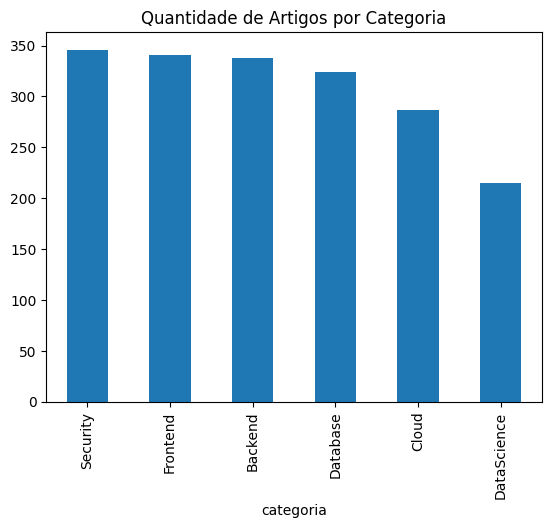

In [7]:
# Checagem Balanceamento
df['categoria'].value_counts().plot(kind='bar', title='Quantidade de Artigos por Categoria')

### Valores Duplicados

In [8]:
# Verificando registros duplicados por linha
df.duplicated().sum()

np.int64(0)

In [9]:
# Quantidade de registros duplicados por id 
df['id'].duplicated().sum()

np.int64(253)

In [10]:
# Verificando Ids duplicados
df[df['id'].duplicated(keep=False)].sort_values('id')[['categoria', 'subcategoria', 'id', 'texto', 'tags']].head(5)

,categoria,subcategoria,id,texto,tags
857,Cloud,azure,3450296,creating a folder and initializing github for ...,"devops, azure, cloud, cloudcomputing"
718,Cloud,cloud,3450296,creating a folder and initializing github for ...,"devops, azure, cloud, cloudcomputing"
816,Cloud,aws,3509884,> **One-liner:** Pub-Sub lets publishers broad...,"aws, systemdesign, devops, backend"
377,Backend,backend,3509884,> **One-liner:** Pub-Sub lets publishers broad...,"aws, systemdesign, devops, backend"
1704,DataScience,machinelearning,3790359,"---\ndescription: ""SDAR claims it beats GRPO a...","aws, machinelearning, mlops, reinforcementlear..."


Há registros duplicados por id. Isso ocorre porque a base é obtida através da subcategoria, que no caso pode ser diferente. Os registros duplicados serão descartados.

Há registros duplicado por id, porém de categorias diferentes. Verificar quantos casos desse tipo.



In [11]:
# Quantidade de conflitos (id igual e categoria diferente)
conflitos = df[df['id'].duplicated(keep=False)].groupby('id')['categoria'].nunique()
(conflitos > 1).sum()

np.int64(71)

In [12]:
# Verificando registros com conflitos
ids_conflito = conflitos[conflitos > 1].index

df[df['id'].isin(ids_conflito)].sort_values('id')[['categoria', 'subcategoria', 'id', 'texto', 'tags']].head(10)

,categoria,subcategoria,id,texto,tags
377,Backend,backend,3509884,> **One-liner:** Pub-Sub lets publishers broad...,"aws, systemdesign, devops, backend"
816,Cloud,aws,3509884,> **One-liner:** Pub-Sub lets publishers broad...,"aws, systemdesign, devops, backend"
800,Cloud,aws,3790359,"---\ndescription: ""SDAR claims it beats GRPO a...","aws, machinelearning, mlops, reinforcementlear..."
1704,DataScience,machinelearning,3790359,"---\ndescription: ""SDAR claims it beats GRPO a...","aws, machinelearning, mlops, reinforcementlear..."
1297,Security,security,3965827,"---\ntitle: ""Create and secure webhooks with t...","api, webhooks, security, devtools"
511,Backend,api,3965827,"---\ntitle: ""Create and secure webhooks with t...","api, webhooks, security, devtools"
342,Backend,backend,4056069,I don lose count of how many times I don see t...,"backend, reviews, architecture, database"
967,Database,database,4056069,I don lose count of how many times I don see t...,"backend, reviews, architecture, database"
516,Backend,api,4107706,\n\n## TL;DR\n\n- Best Sanity CMS use cases in...,"api, nextjs, saas, webdev"
286,Frontend,nextjs,4107706,\n\n## TL;DR\n\n- Best Sanity CMS use cases in...,"api, nextjs, saas, webdev"


São 71 casos com textos iguais e categorias diferentes 

### Valores Nulos | Vazios

In [13]:
# Quantidade valores nulos
df[['texto', 'categoria']].isnull().sum()

texto        3
categoria    0
dtype: int64

In [14]:
# Verificando valores nulos
df[df['texto'].isnull()]

,categoria,collection_id,comments_count,created_at,crossposted_at,description,edited_at,flare_tag,id,language,...,published_timestamp,readable_publish_date,reading_time_minutes,subcategoria,subforem_id,tag_list,tags,texto,title,type_of
1062,Database,NaN,0,2026-07-15T00:50:41Z,NaN,The Problem Real411 is a South African platf...,2026-07-15T01:17:07Z,NaN,4145479,en,...,2026-07-15T00:50:41Z,Jul 15,0,postgres,1.0,"['architecture', 'aws', 'workflow', 'postgres']","architecture, aws, workflow, postgres",NaN,Designing a Three Reviewer Consensus Platform ...,article
1494,Security,NaN,0,2026-07-12T06:53:23Z,NaN,A post by Michael Olowoselu,NaN,NaN,4123808,en,...,2026-07-12T06:53:23Z,Jul 12,0,infosec,1.0,"['cybersecurity', 'infosec', 'monitoring', 'se...","cybersecurity, infosec, monitoring, security",NaN,Be aware of abnormal activity’s and patterns t...,article
1848,DataScience,NaN,0,2026-07-18T14:57:19Z,NaN,A post by ifham,2026-07-18T14:59:19Z,NaN,4174423,en,...,2026-07-18T14:57:19Z,Jul 18,0,python,1.0,"['ai', 'llm', 'mcp', 'python']","ai, llm, mcp, python",NaN,Would you like to give me suggestions on how t...,article


Há 3 registros com texto nulo. Serão descartados.

In [15]:
# Verificando se há registros onde o texto é somente vazio ou em branco
(df['texto'].astype(str).str.strip() == '').sum()

np.int64(0)

In [16]:
# Verificando se há registros onde a categoria é vazia ou em branco
(df['categoria'].astype(str).str.strip() == '').sum()

np.int64(0)

### Análise do Texto

In [17]:
# Verificando textos duplicados
df[df['texto'].duplicated(keep=False)].sort_values('texto')[['categoria', 'subcategoria', 'id', 'texto', 'tags']].head(5)


,categoria,subcategoria,id,texto,tags
516,Backend,api,4107706,\n\n## TL;DR\n\n- Best Sanity CMS use cases in...,"api, nextjs, saas, webdev"
286,Frontend,nextjs,4107706,\n\n## TL;DR\n\n- Best Sanity CMS use cases in...,"api, nextjs, saas, webdev"
1270,Database,crud,1819629,"\n\nI'm setting up a CRUD system with Django, ...","python, django, http, crud"
1269,Database,crud,1819628,"\n\nI'm setting up a CRUD system with Django, ...","python, django, http, crud"
113,Frontend,javascript,4174671,\n\nReact is one of the most popular JavaScrip...,"react, web, seo, javascript"


Verificamos que há registros com texto duplicados com o mesmo id e também com id diferente

In [18]:
# Verificando registros com textos identicos e id´s diferentes
duplicados = df[df['texto'].duplicated(keep=False)]
grupos_id_diferente = duplicados.groupby('texto')['id'].nunique()

# Quantidade de textos duplicados com id diferente
(grupos_id_diferente > 1).sum()

np.int64(6)

In [19]:
# Visualizando textos duplicados com id´s diferentes
textos_id_diferente = grupos_id_diferente[grupos_id_diferente > 1].index

df[df['texto'].isin(textos_id_diferente)].sort_values('texto')[['categoria', 'subcategoria', 'id', 'texto', 'tags']]

,categoria,subcategoria,id,texto,tags
1269,Database,crud,1819628,"\n\nI'm setting up a CRUD system with Django, ...","python, django, http, crud"
1270,Database,crud,1819629,"\n\nI'm setting up a CRUD system with Django, ...","python, django, http, crud"
1591,Security,ethicalhacking,4040758,# The Step-by-Step Process of Penetration Test...,"penetrationtesting, ethicalhacking, cybersecur..."
1586,Security,ethicalhacking,4040607,# The Step-by-Step Process of Penetration Test...,"penetrationtesting, ethicalhacking, cybersecur..."
1173,Database,sql,4153247,Most data questions start in plain English.\n\...,"python, ai, flask, sql"
1181,Database,sql,4153348,Most data questions start in plain English.\n\...,"python, ai, flask, sql"
1372,Security,mfa,3066817,Online security is a top priority for business...,"azure, microsoft365, mfa"
1371,Security,mfa,3096643,Online security is a top priority for business...,"azure, mfa, microsoft365"
74,Frontend,javascript,4173833,{% embed https://dev.to/anthonymax/typescript-...,"javascript, news, programming, typescript"
239,Frontend,typescript,4173833,{% embed https://dev.to/anthonymax/typescript-...,"javascript, news, programming, typescript"


Para os registros com textos identicos, categoria e id´s, será mantido um deles. 

Os registros que possuem o texto  "{{ $json.postContent }}" serão descartados pois são inviáveis para treinamento

In [20]:
# Há mais textos desse tipo ? 
padroes_ruins = df['texto'].astype(str).str.match(r'^\s*(\{\{.*\}\}|\{%.*%\})\s*$')
padroes_ruins.sum()

np.int64(24)

In [21]:
# Visualizando registros do mesmo tipo  
df[padroes_ruins][['categoria', 'subcategoria', 'id', 'texto', 'tags']]

,categoria,subcategoria,id,texto,tags
49,Frontend,frontend,4132153,{% embed https://dev.to/parsajiravand/you-cant...,"css, frontend, tutorial, webdev"
74,Frontend,javascript,4173833,{% embed https://dev.to/anthonymax/typescript-...,"javascript, news, programming, typescript"
84,Frontend,javascript,4173937,{% embed https://dev.to/anthonymax/typescript-...,"javascript, news, typescript, webdev"
194,Frontend,css,4132153,{% embed https://dev.to/parsajiravand/you-cant...,"css, frontend, tutorial, webdev"
198,Frontend,css,4127183,{% embed https://dev.to/piyushpatil1243/glassm...,"css, tutorial, ui, webdev"
239,Frontend,typescript,4173833,{% embed https://dev.to/anthonymax/typescript-...,"javascript, news, programming, typescript"
246,Frontend,typescript,4173937,{% embed https://dev.to/anthonymax/typescript-...,"javascript, news, typescript, webdev"
387,Backend,backend,4160310,{% embed https://dev.to/edpittol/your-fileexis...,"aws, backend, performance, php"
585,Backend,php,4160310,{% embed https://dev.to/edpittol/your-fileexis...,"aws, backend, performance, php"
761,Cloud,kubernetes,4158249,{% embed https://dev.to/zubairakbar/slurm-vs-k...,"ai, infrastructure, kubernetes, machinelearning"


In [22]:
# Conferindo se são somente embed´s
df[padroes_ruins][['id', 'texto']].values

array([[4132153,
        '{% embed https://dev.to/parsajiravand/you-cant-transition-a-css-variable-property-says-otherwise-50a0 minimal %}'],
       [4173833,
        '{% embed https://dev.to/anthonymax/typescript-7-is-officially-released-4i7m minimal %}'],
       [4173937,
        '{% embed https://dev.to/anthonymax/typescript-7-is-officially-released-4i7m minimal %}'],
       [4132153,
        '{% embed https://dev.to/parsajiravand/you-cant-transition-a-css-variable-property-says-otherwise-50a0 minimal %}'],
       [4127183,
        '{% embed https://dev.to/piyushpatil1243/glassmorphic-profile-card-using-css-4omd minimal %}'],
       [4173833,
        '{% embed https://dev.to/anthonymax/typescript-7-is-officially-released-4i7m minimal %}'],
       [4173937,
        '{% embed https://dev.to/anthonymax/typescript-7-is-officially-released-4i7m minimal %}'],
       [4160310,
        '{% embed https://dev.to/edpittol/your-fileexists-is-secretly-a-network-call-4236 minimal %}'],
       [41

O texto inteiro do campo é só a marcação de embed. Registros devem ser descartados por não serem viáveis para treinamento do modelo 

In [23]:
# Há marcações no meio do texto ?
tem_marcacao = df['texto'].astype(str).str.contains(r'\{%.*?%\}|\{\{.*?\}\}')
tem_marcacao.sum() 

np.int64(113)

In [24]:
# Visualizando textos
df[tem_marcacao][['categoria', 'subcategoria', 'id', 'texto']].sample(10)

,categoria,subcategoria,id,texto
228,Frontend,typescript,4175536,Choosing a state management library feels a bi...
49,Frontend,frontend,4132153,{% embed https://dev.to/parsajiravand/you-cant...
116,Frontend,react,4175536,Choosing a state management library feels a bi...
949,Cloud,docker,4142805,## Introduction \n\nIf you’re looking for a *...
1725,DataScience,machinelearning,4176278,{{ $json.postContent }}
777,Cloud,kubernetes,4150591,\n![cover image](https://dev-to-uploads.s3.us-...
47,Frontend,frontend,4134714,**PrimeNG's new licensing model** and **A2UI f...
87,Frontend,javascript,4168804,---\ntitle: React Native Interview Handbook — ...
214,Frontend,css,4136042,\nCSS is capable of expressing a lot when it c...
112,Frontend,javascript,4168806,---\ntitle: React Native Interview Handbook — ...


A maioria tem conteudo real 

In [25]:
# Quantidade de palavras dos textos
df['contagem_palavras'] = df['texto'].str.split().str.len()
df['contagem_palavras'].value_counts().sort_index().reset_index()

,contagem_palavras,count
0,3.0,8
1,4.0,1
2,5.0,15
3,20.0,1
4,26.0,1
...,...,...
1137,7406.0,1
1138,9129.0,1
1139,10572.0,2
1140,10731.0,2


Há 24 textos com menos de 20 palavras. 

In [26]:
# Quantidade de palavras acima de 19 
df[df['contagem_palavras'] > 19]['contagem_palavras'].sort_values().head(10)

1633    20.0
1602    26.0
1631    31.0
1134    33.0
197     37.0
1514    39.0
632     41.0
1235    41.0
127     42.0
1570    44.0
Name: contagem_palavras, dtype: float64

In [27]:
# Verificando o texto com 20 palavras 
df.loc[1633, 'texto']

"Read Hackersprey's latest blog on Why Your Network Security is Still Failing and How Firewalls Actually Evolved.\nhttps://www.hackersprey.com/blog/why-your-network-security-is-still-failing\n\n![Image description](https://dev-to-uploads.s3.amazonaws.com/uploads/articles/jwac12dvi5w0f88brsht.png)"

Consideramos que texto seria útil para treinamento. 
Textos considerados serão os que tiverem acima de 20 palavras 

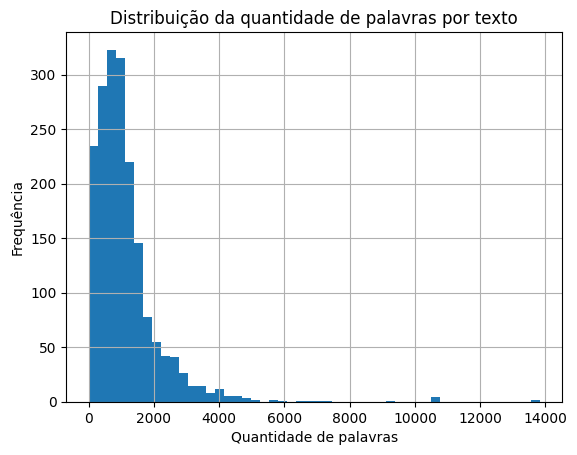

In [28]:
# Distribuição dos textos por quantidade de palavras 
df['contagem_palavras'].hist(bins=50)
plt.xlabel('Quantidade de palavras')
plt.ylabel('Frequência')
plt.title('Distribuição da quantidade de palavras por texto')
plt.show()

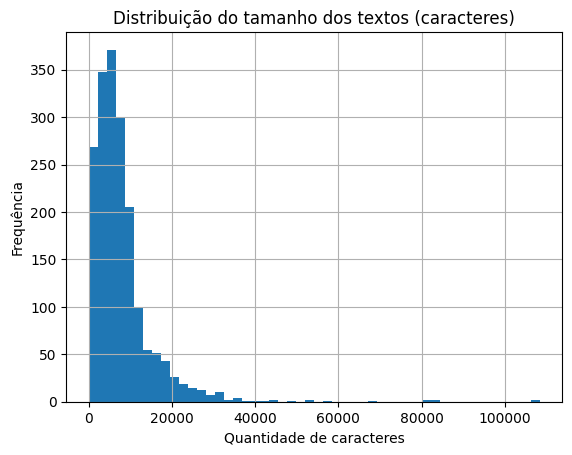

In [29]:
# Distribuição dos textos por quantidade de caracteres 
df['tamanho_texto'] = df['texto'].str.len()

df['tamanho_texto'].hist(bins=50)
plt.xlabel('Quantidade de caracteres')
plt.ylabel('Frequência')
plt.title('Distribuição do tamanho dos textos (caracteres)')
plt.show()

## Preparação dos Dados

### Remoção de Colunas 


In [30]:
# Remoção inicial de colunas
df = df[['id', 'categoria', 'subcategoria', 'texto', 'tags', 'title']]

In [31]:
# Conferindo estrutura
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1851 entries, 0 to 1850
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            1851 non-null   int64 
 1   categoria     1851 non-null   object
 2   subcategoria  1851 non-null   object
 3   texto         1848 non-null   object
 4   tags          1851 non-null   object
 5   title         1851 non-null   object
dtypes: int64(1), object(5)
memory usage: 86.9+ KB


### Limpeza e Preparação dos Textos

#### Códigos pesquisa Kaylane

In [ ]:
"""
# LIMPEZA E PREPARAÇÃO DOS TEXTOS 

# 1. REMOÇÃO DE TEXTOS NULOS / VAZIOS 
# Remove registros sem conteúdo.

df = df.dropna(subset=["body"])



# ==========================================================

# 2. REMOÇÃO DE TEXTOS DUPLICADOS
# Remove documentos repetidos da base.

df = df.drop_duplicates(subset=["body"])



# ==========================================================

# 3. DETECÇÃO DE IDIOMA
# Identifica o idioma do texto.Útil para manter apenas textos em inglês.

from langdetect import detect

def detect_language(text):

    try:
        return detect(text)

    except:
        return "unknown"



# ==========================================================

# 4. REMOÇÃO DE HTML
# Remove tags HTML presentes no texto.

from bs4 import BeautifulSoup

def remove_html(text):
    return BeautifulSoup(text, "html.parser").get_text()



# ==========================================================

# 5. REMOÇÃO DE URLs
# Remove links presentes no texto.

import re

def remove_urls(text):
    return re.sub(r"http\S+|www\S+", "", text)



# ==========================================================

# 6. REMOÇÃO DE E-MAILS
# Remove endereços de e-mail.

def remove_emails(text):
    return re.sub(r"\S+@\S+", "", text)



# ==========================================================

# 7. CONVERSÃO PARA LETRAS MINÚSCULAS

def lowercase(text):
    return text.lower()



# ==========================================================

# 8. EXPANSÃO DE CONTRAÇÕES (Opcional)
# Exemplo:
# don't -> do not

import contractions

def expand_contractions(text):
    return contractions.fix(text)



# ==========================================================

# 9. REMOÇÃO DE EMOJIS
# Remove emojis e símbolos gráficos.

import emoji

def remove_emojis(text):
    return emoji.replace_emoji(text, replace="")



# ==========================================================

# 10. REMOÇÃO DE CARACTERES ESPECIAIS
# Mantém apenas letras e espaços.

def remove_special_characters(text):
    return re.sub(r"[^a-zA-Z\s]", "", text)



# ==========================================================

# 11. REMOÇÃO DE PONTUAÇÕES
# Remove pontuações quando elas não forem relevantes.
# Atenção:
# Em textos técnicos pode ser necessário preservar termos
# como C++, C#, .NET, Node.js e TF-IDF.

def remove_punctuation(text):
    return re.sub(r"[^\w\s]", "", text)



# ==========================================================

# 12. REMOÇÃO DE NÚMEROS (Opcional)
# Remove números do texto.

def remove_numbers(text):
    return re.sub(r"\d+", "", text)



# ==========================================================

# 13. REMOÇÃO DE ESPAÇOS EXTRAS
# Padroniza os espaços.

def remove_extra_spaces(text):
    return " ".join(text.split())



# ==========================================================

# 14. TOKENIZAÇÃO
# Divide o texto em palavras.

import spacy

nlp = spacy.load("en_core_web_sm")

def tokenize(text):

    doc = nlp(text)

    return [token.text for token in doc]



# ==========================================================

# 15. REMOÇÃO DE STOP WORDS
# Remove palavras muito frequentes da língua inglesa.

def remove_stopwords(text):

    doc = nlp(text)

    words = [token.text for token in doc if not token.is_stop]

    return " ".join(words)



# ==========================================================

# 16. LEMMATIZATION
# Converte palavras para sua forma base.

def lemmatize(text):

    doc = nlp(text)

    return " ".join(token.lemma_ for token in doc)



# ==========================================================

# 17. STEMMING (Alternativa)
# Reduz palavras ao radical.

from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

stemmer = PorterStemmer()

def stemming(text):

    tokens = word_tokenize(text)

    return " ".join(stemmer.stem(token) for token in tokens)



# ==========================================================
# TÉCNICAS COMPLEMENTARES
# ==========================================================

# ----------------------------------------------------------
# Remover palavras muito curtas
# ----------------------------------------------------------

def remove_short_words(text):

    words = text.split()

    words = [word for word in words if len(word) > 2]

    return " ".join(words)


# ----------------------------------------------------------
# Remover acentos
# ----------------------------------------------------------

from unidecode import unidecode

def remove_accents(text):
    return unidecode(text)


# ----------------------------------------------------------
# Normalização Unicode
# ----------------------------------------------------------

import unicodedata

def normalize_unicode(text):
    return unicodedata.normalize("NFKC", text)

    """


#### Encoding (Se aplicável)

#### TF-IDF (vetorização)

## Modelagem

#### Separação de Dados

In [33]:
# Variável de entrada e target

In [34]:
# Treino e teste

#### Criação de Modelo

## Avaliação do Modelo

## Extração de Palavras-Chave

## Serialização do Modelo

In [35]:
## OBS: preencher somente no notebook final consolidado com os 3 modelos. Após escolha do modelo com melhor performance

## Exemplos de Uso (JSON)

In [36]:
## OBS: preencher somente no notebook final consolidado com os 3 modelos. Após escolha do modelo com melhor performance

# Carregar o modelo salvo: modelo = joblib.load('modelo.pkl')
# Criar 3 textos de exemplo (como se fossem o que o usuário mandaria pra API)
# Rodar o modelo nesses textos e montar a saída no formato JSON esperado (igual ao exemplo do enunciado)

## Conclusões